In [65]:
! pip install -q yfinance

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [67]:
ticker = "JPM"          # Change to any stock, e.g. MSFT, TSLA, JPM
start_date = "2020-01-01"
end_date = "2025-01-01"

In [68]:
short_window = 20
long_window = 50

In [69]:
df = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [70]:
#needed columns selected:
df = df[["Close"]].copy()
df.dropna(inplace=True)


In [71]:
df = df[["Close"]].copy()
df.dropna(inplace=True)

creating moving avrgs

In [72]:
df["SMA_short"] = df["Close"].rolling(window=short_window).mean()
df["SMA_long"] = df["Close"].rolling(window=long_window).mean()

In [73]:
#unwanted rows drop
df.dropna(inplace=True)

In [74]:
# Signal = 1 when short MA > long MA, else 0/ setting frames for condition
df["Signal"] = 0
df.loc[df["SMA_short"] > df["SMA_long"], "Signal"] = 1

In [75]:
#1 buy/ -1 sell
df["Position"] = df["Signal"].diff()

In [76]:
#daily returns values
df["Market_Return"] = df["Close"].pct_change()

In [77]:
#lets avoid look-ahead bias
df["Strategy_Return"] = df["Market_Return"] * df["Signal"].shift(1)

In [78]:
df["Strategy_Return"] = df["Market_Return"] * df["Signal"].shift(1)

In [79]:
# cumprod for finding cumulative returns/*learn and practise cumprod use cases more
df["Cumulative_Market"] = (1 + df["Market_Return"]).cumprod()
df["Cumulative_Strategy"] = (1 + df["Strategy_Return"]).cumprod()

In [80]:
df["Cumulative_Market"] = (1 + df["Market_Return"]).cumprod()
df["Cumulative_Strategy"] = (1 + df["Strategy_Return"]).cumprod()

perfomance metrics


In [81]:
def annualized_return(returns, periods_per_year=252):
    compounded_growth = (1 + returns).prod()
    n_periods = len(returns)
    return compounded_growth ** (periods_per_year / n_periods) - 1

def annualized_volatility(returns, periods_per_year=252):
    return returns.std() * np.sqrt(periods_per_year)

def sharpe_ratio(returns, risk_free_rate=0.0, periods_per_year=252):
    ann_ret = annualized_return(returns, periods_per_year)
    ann_vol = annualized_volatility(returns, periods_per_year)
    if ann_vol == 0:
        return np.nan
    return (ann_ret - risk_free_rate) / ann_vol

def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns / running_max) - 1
    return drawdown.min()

strategy_ann_return = annualized_return(df["Strategy_Return"])
market_ann_return = annualized_return(df["Market_Return"])

strategy_ann_vol = annualized_volatility(df["Strategy_Return"])
market_ann_vol = annualized_volatility(df["Market_Return"])

strategy_sharpe = sharpe_ratio(df["Strategy_Return"])
market_sharpe = sharpe_ratio(df["Market_Return"])

strategy_mdd = max_drawdown(df["Cumulative_Strategy"])
market_mdd = max_drawdown(df["Cumulative_Market"])

# Calculate values of portfolio with initial capital
initial_capital = 10000
df['Portfolio_Strategy'] = initial_capital * df['Cumulative_Strategy']
df['Portfolio_Market'] = initial_capital * df['Cumulative_Market']



In [82]:
print(f"\nBacktest Results for {ticker}")
print("-" * 40)
print(f"Strategy Annualized Return:   {strategy_ann_return:.2%}")
print(f"Buy & Hold Annualized Return: {market_ann_return:.2%}")
print(f"Strategy Volatility:          {strategy_ann_vol:.2%}")
print(f"Buy & Hold Volatility:        {market_ann_vol:.2%}")
print(f"Strategy Sharpe Ratio:        {strategy_sharpe:.2f}")
print(f"Buy & Hold Sharpe Ratio:      {market_sharpe:.2f}")
print(f"Strategy Max Drawdown:        {strategy_mdd:.2%}")
print(f"Buy & Hold Max Drawdown:      {market_mdd:.2%}")
print(f"Final Strategy Portfolio:     ${df['Portfolio_Strategy'].iloc[-1]:,.2f}")
print(f"Final Buy & Hold Portfolio:   ${df['Portfolio_Market'].iloc[-1]:,.2f}")


Backtest Results for JPM
----------------------------------------
Strategy Annualized Return:   17.37%
Buy & Hold Annualized Return: 22.51%
Strategy Volatility:          20.85%
Buy & Hold Volatility:        30.35%
Strategy Sharpe Ratio:        0.83
Buy & Hold Sharpe Ratio:      0.74
Strategy Max Drawdown:        -23.82%
Buy & Hold Max Drawdown:      -38.77%
Final Strategy Portfolio:     $21,561.43
Final Buy & Hold Portfolio:   $26,485.85


In [83]:
#diagram display of the signals

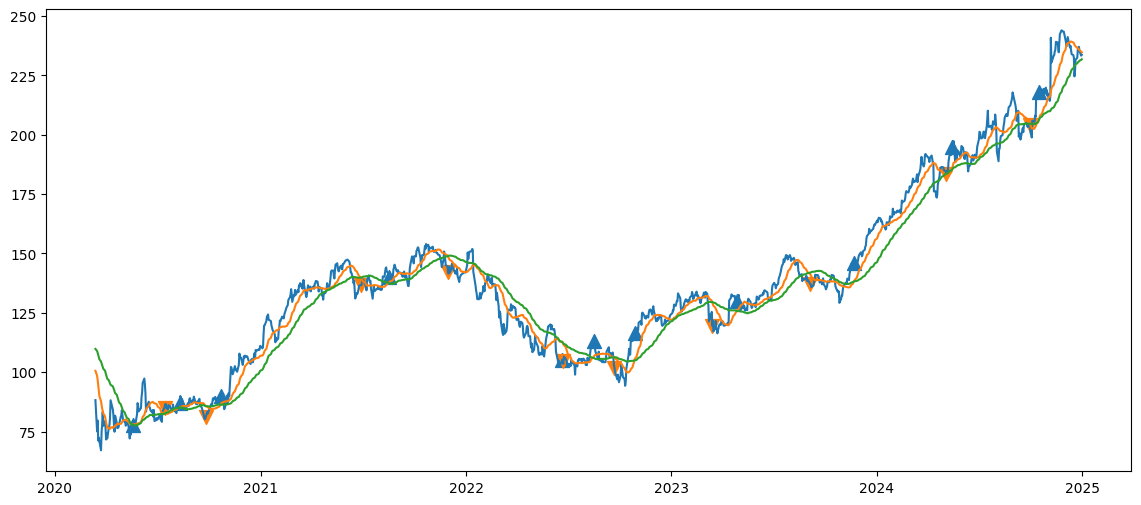

In [84]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["SMA_short"], label=f"SMA {short_window}")
plt.plot(df.index, df["SMA_long"], label=f"SMA {long_window}")

buy_signals = df[df["Position"] == 1]
sell_signals = df[df["Position"] == -1]

plt.scatter(
    buy_signals.index,
    buy_signals["Close"],
    label="Buy Signal",
    marker="^",
    s=100
)


#sell signals
plt.scatter(
    sell_signals.index,
    sell_signals["Close"],
    label="Sell Signal",
    marker="v",
    s=100
)


/tmp/ipykernel_617/3683547763.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


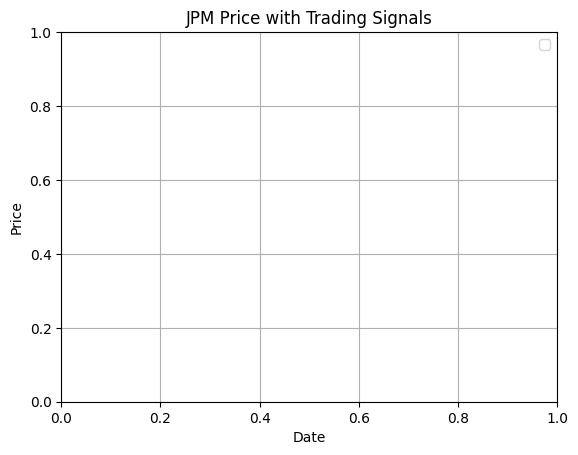

In [85]:
plt.title(f"{ticker} Price with Trading Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

print the cumulative returns


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Cumulative_Market"], label="Buy & Hold")
plt.plot(df.index, df["Cumulative_Strategy"], label="Strategy")
plt.title(f"{ticker} Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Portfolio_Market"], label="Buy & Hold Portfolio")
plt.plot(df.index, df["Portfolio_Strategy"], label="Strategy Portfolio")
plt.title(f"{ticker} Portfolio Value (Initial Capital = ${initial_capital:,})")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#final dataframe ready check
df.tail(10)